# Signal Processing

Signal processing involves transforming signals to extract useful information, reduce unwanted components, or change their representation. In this notebook, the same noisy signal is processed using correlation, convolution, filtering, and resampling techniques.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [2]:
plt.rcParams.update({ "font.family": "Times New Roman", "mathtext.fontset": "cm", "font.size": 14 })

The signal is sampled at

$$
f_s = 1000\ \text{Hz}
$$

over a duration of

$$
T = 10\ \text{s}.
$$

A clean signal is constructed from several components and combined with Gaussian noise:

$$
x_{\mathrm{noisy}}(t) = x_{\mathrm{clean}}(t)+\eta(t).
$$

In [3]:
fs, T = 1000, 10
t = np.linspace(0, T, int(fs * T), endpoint=False)
x_clean = (np.sin(8 * np.pi * t)
    + 0.2 * (1 + np.sin(10 * np.pi * t)) * np.sin(12 * np.pi * t)
    + 0.2 * np.sin(4 * np.pi * t + np.sin(6 * np.pi * t))
    + 0.5 * np.exp(-t) * np.cos(2 * np.pi * t))
x_noisy = x_clean + np.random.normal(0, 0.1, len(t))

The clean and noisy signals are first compared to illustrate the effect of measurement noise.

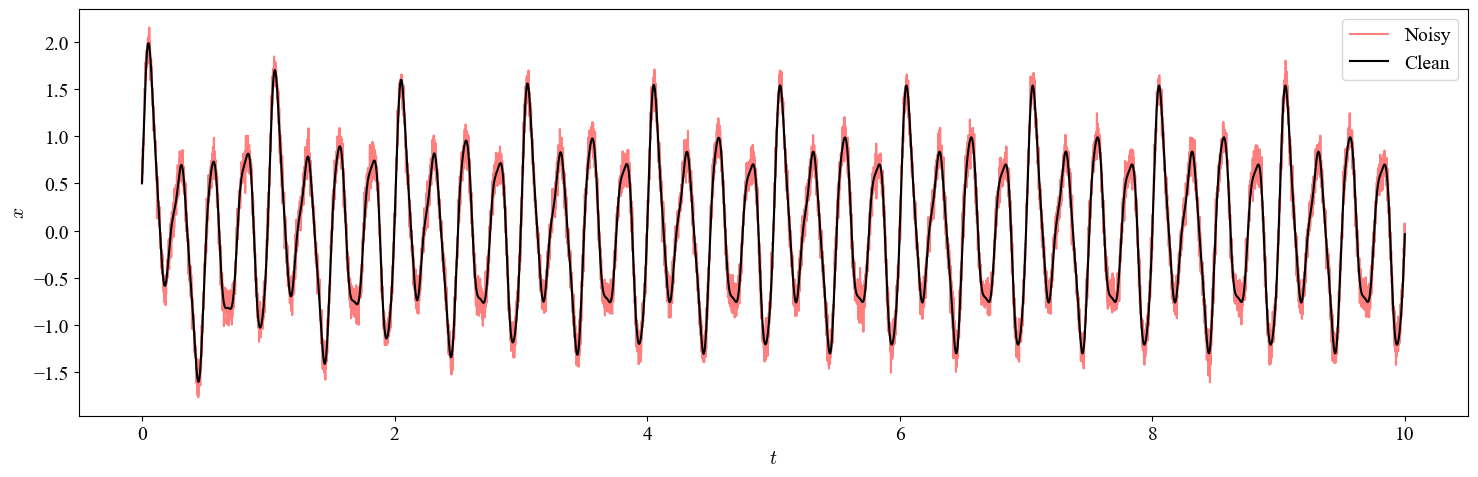

In [4]:
plt.figure(figsize=(15, 5))
plt.plot(t, x_noisy, "r", alpha=0.5, label="Noisy")
plt.plot(t, x_clean, "k", label="Clean")
plt.xlabel(r"$t$")
plt.ylabel(r"$x$")
plt.legend()
plt.tight_layout()
plt.show()

## Correlation

Correlation measures the similarity between a signal and shifted versions of another signal. The discrete cross-correlation is defined as

$$
R_{xy}[k] = \sum_n x[n]\,y[n+k].
$$

For an autocorrelation, the signal is correlated with itself:

In [5]:
corr = signal.correlate(x_noisy, x_noisy, mode="full")
lags = signal.correlation_lags(len(x_noisy), len(x_noisy), mode="full")

The resulting correlation is plotted against the corresponding lag. Large values indicate shifts for which the signal has a strong similarity with itself.

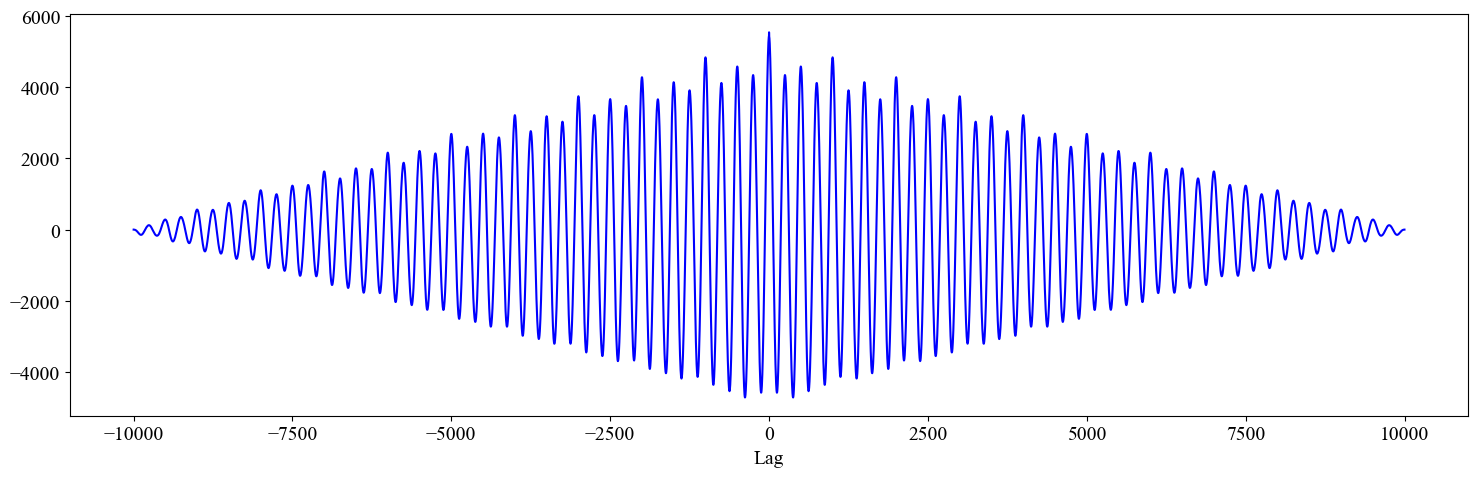

In [6]:
plt.figure(figsize=(15, 5))
plt.plot(lags, corr, "b")
plt.xlabel(r"Lag")
plt.tight_layout()
plt.show()

## Convolution

Convolution combines a signal with a kernel to produce a transformed signal:

$$
y[n] = \sum_k x[k]\,h[n-k],
$$

where $h[n]$ is the convolution kernel.

In [7]:
kernel = signal.windows.gaussian(51, std=7)
kernel /= kernel.sum()
conv = {
    "Moving Average": (signal.convolve(x_noisy, np.ones(25) / 25, mode="same"), "r"),
    "Gaussian": (signal.convolve(x_noisy, kernel, mode="same"), "b"),
    "Gaussian FFT": (signal.fftconvolve(x_noisy, kernel, mode="same"), "k"),
}

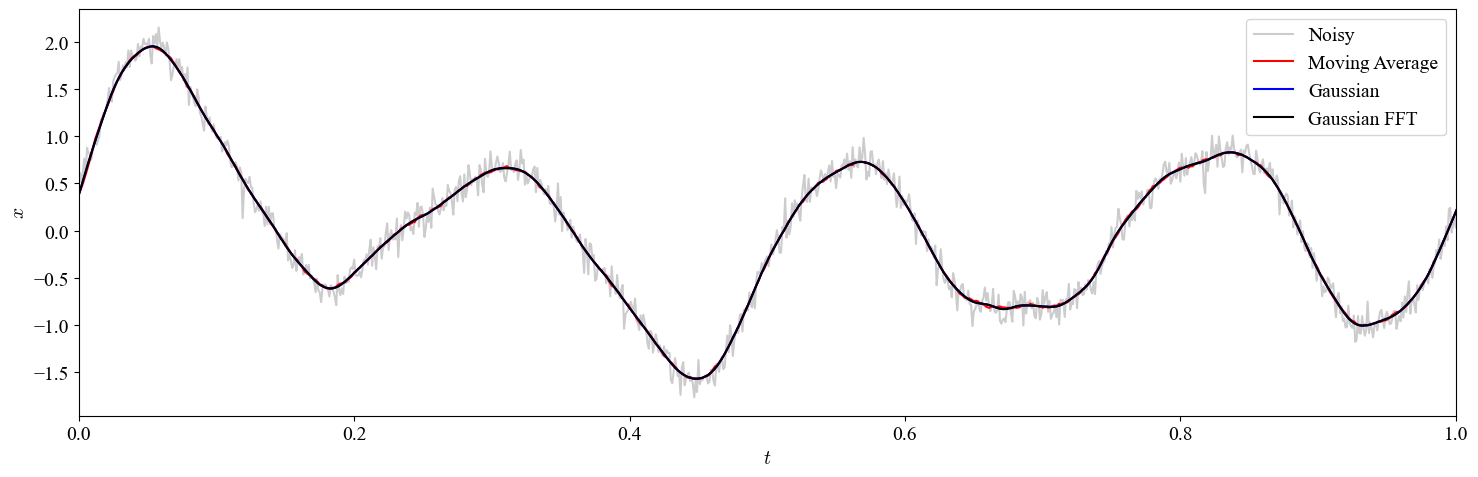

In [8]:
plt.figure(figsize=(15, 5))
plt.plot(t, x_noisy, "k", alpha=0.2, label="Noisy")
for label, (x_conv, color) in conv.items():
    plt.plot(t, x_conv, color=color, label=label)
plt.xlim(0, 1)
plt.xlabel(r"$t$")
plt.ylabel(r"$x$")
plt.legend()
plt.tight_layout()
plt.show()

## Filtering

A filter modifies the frequency content of a signal by attenuating selected frequency components. Three common types are considered:

* **Low-pass:** retains low frequencies and attenuates high frequencies.
* **High-pass:** retains high frequencies and attenuates low frequencies.
* **Band-pass:** retains frequencies within a specified range.

For example, a fourth-order Butterworth filter is constructed using

In [9]:
filters = {
    "Low-pass": (signal.butter(4, 8, fs=fs), "r"),
    "High-pass": (signal.butter(4, 8, btype="highpass", fs=fs), "b"),
    "Band-pass": (signal.butter(4, [1, 8], btype="bandpass", fs=fs), "k"),
}

and applied using zero-phase filtering:

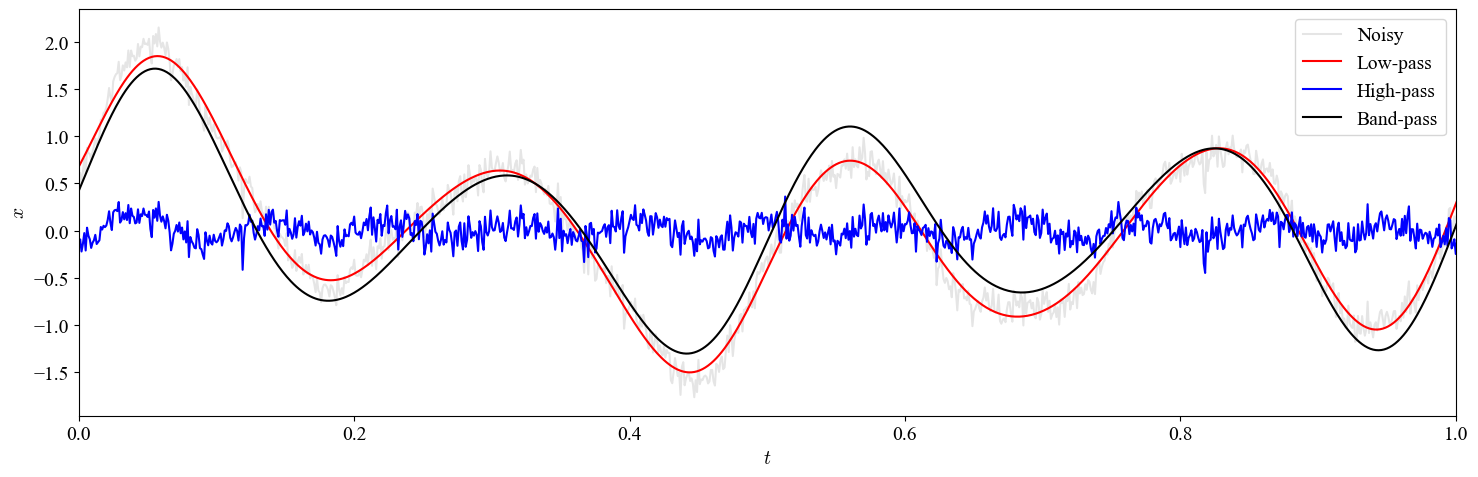

In [10]:
plt.figure(figsize=(15, 5))
plt.plot(t, x_noisy, "k", alpha=0.1, label="Noisy")
for label, ((b, a), color) in filters.items():
    plt.plot(t, signal.filtfilt(b, a, x_noisy), color, label=label)
plt.xlim(0, 1)
plt.xlabel(r"$t$")
plt.ylabel(r"$x$")
plt.legend()
plt.tight_layout()
plt.show()

## Frequency Response

The effect of a filter can be examined through its frequency response. For a digital filter with transfer function

$$
H(e^{i\omega}),
$$

the magnitude response is

$$
|H(e^{i\omega})|.
$$

It is commonly expressed in decibels as

$$
G(f) = 20\log_{10}|H(f)|.
$$

The frequency response can be obtained using `signal.freqz(b, a, fs=fs)` and plotted as

c:\Program Files\Python314\Lib\site-packages\scipy\signal\_filter_design.py:565: RuntimeWarning: invalid value encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /


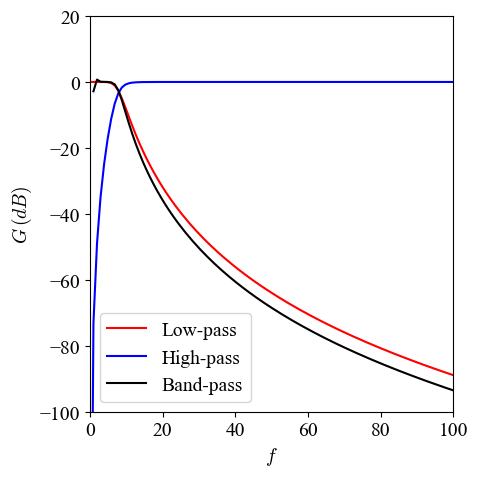

In [11]:
plt.figure(figsize=(5, 5))
for label, ((b, a), color) in filters.items():
    w, h = signal.freqz(b, a, fs=fs)
    plt.plot(w, 20 * np.log10(np.abs(h)), color=color, label=label)
plt.xlim(0, 100)
plt.ylim(-100, 20)
plt.xlabel(r"$f$")
plt.ylabel(r"$G\,(dB)$")
plt.legend()
plt.tight_layout()
plt.show()

A value of

$$
G = 0\ \text{dB}
$$

corresponds to unit gain, while negative values indicate attenuation.

## Filter Families

Different filter designs provide different compromises between transition sharpness, passband behavior, stopband attenuation, and phase characteristics. Several low-pass filters are compared:

In [12]:
lowpass_filters = {
    "Median Filter": (signal.medfilt(x_noisy, kernel_size=51), "navy"),
    "Butterworth": (signal.filtfilt(*signal.butter(4, 8, fs=fs), x_noisy), "mediumblue"),
    "Chebychev I": (signal.filtfilt(*signal.cheby1(4, 1, 8, fs=fs), x_noisy), "mediumslateblue"),
    "Chebychev II": (signal.filtfilt(*signal.cheby2(4, 40, 8, fs=fs), x_noisy), "blueviolet"),
    "Elliptic": (signal.filtfilt(*signal.ellip(4, 1, 40, 8, fs=fs), x_noisy), "mediumorchid"),
    "Bessel": (signal.filtfilt(*signal.bessel(4, 8, fs=fs), x_noisy), "orchid"),
    "FIR": (signal.filtfilt(signal.firwin(51, 8, fs=fs), [1], x_noisy), "hotpink"),
}

The filters include Butterworth, Chebyshev type I, Chebyshev type II, elliptic, Bessel, and FIR designs.

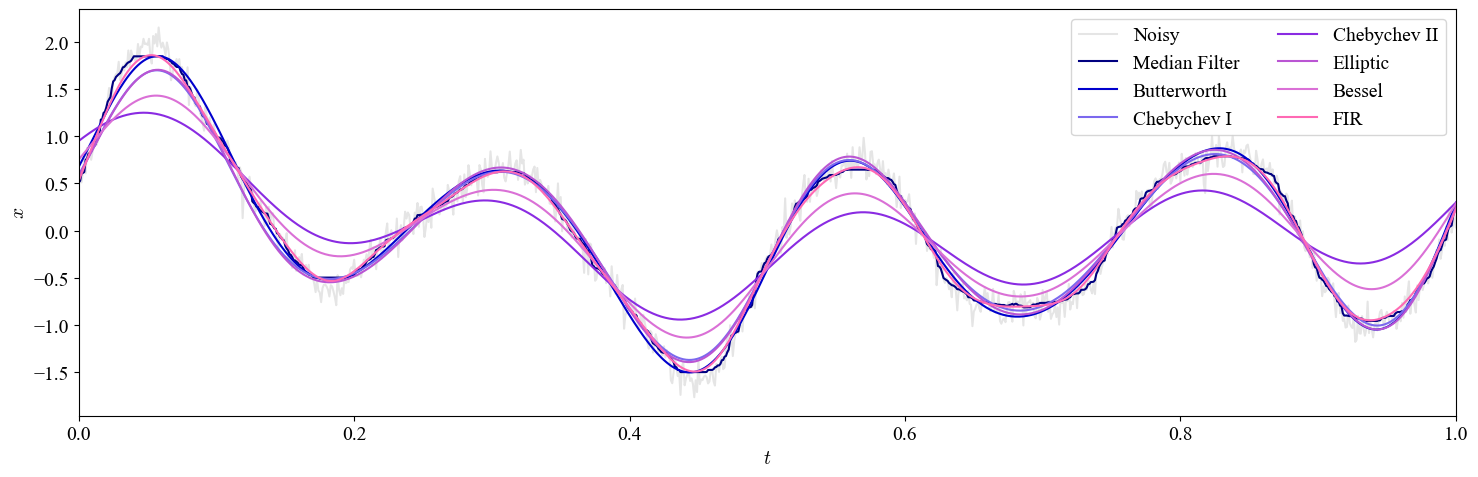

In [13]:
plt.figure(figsize=(15, 5))
plt.plot(t, x_noisy, color="k", alpha=0.1, label="Noisy")
for label, (x_filtered, color) in lowpass_filters.items():
    plt.plot(t, x_filtered, color, label=label)
plt.xlim(0, 1)
plt.xlabel(r"$t$")
plt.ylabel(r"$x$")
plt.legend(loc="upper right", ncol=2)
plt.tight_layout()
plt.show()

In [14]:
lowpass_filters = {
    "Butterworth": (signal.butter(4, 8, fs=fs), "navy"),
    "Chebychev I": (signal.cheby1(4, 1, 8, fs=fs), "mediumblue"),
    "Chebychev II": (signal.cheby2(4, 40, 8, fs=fs), "blueviolet"),
    "Elliptic": (signal.ellip(4, 1, 40, 8, fs=fs), "mediumorchid"),
    "Bessel": (signal.bessel(4, 8, fs=fs), "orchid"),
    "FIR": ((signal.firwin(51, 8, fs=fs), [1]), "hotpink"),
}

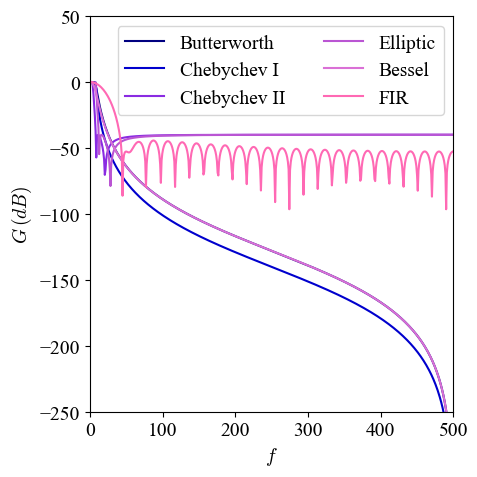

In [15]:
plt.figure(figsize=(5, 5))
for label, ((b, a), color) in lowpass_filters.items():
    w, h = signal.freqz(b, a, fs=fs)
    plt.plot(w, 20 * np.log10(np.abs(h)), color=color, label=label)
plt.xlim(0, 500)
plt.ylim(-250, 50)
plt.xlabel(r"$f$")
plt.ylabel(r"$G\,(dB)$")
plt.legend(loc="upper right", ncol=2)
plt.tight_layout()
plt.show()

Their frequency responses reveal how differently each filter attenuates frequencies outside the passband. The comparison illustrates that filter design is not simply a matter of choosing a cutoff frequency. The filter family and its parameters determine the shape of the resulting frequency response.

## Resampling

Resampling changes the number of samples used to represent a signal. For example,

In [16]:
x_resample = signal.resample(x_noisy, len(x_noisy)//2)
t_resample = np.linspace(0, T, len(x_resample), endpoint=False)

the number of samples is therefore reduced from

$$
N
$$

to

$$
\frac{N}{2}.
$$

The corresponding sampling frequency is also reduced by a factor of two.

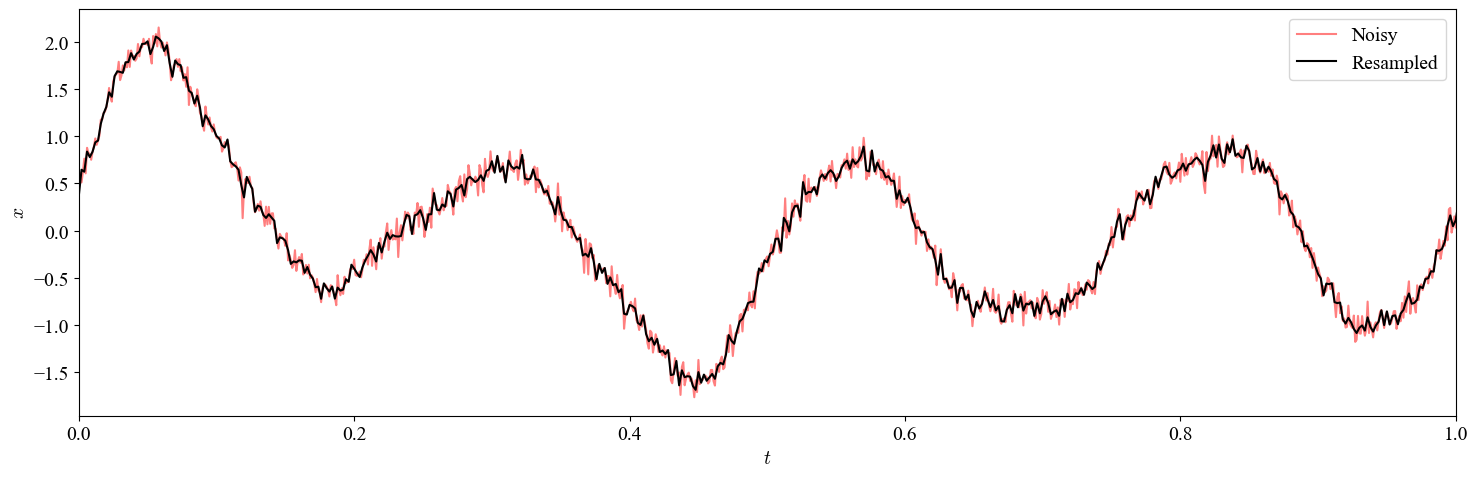

In [17]:
plt.figure(figsize=(15, 5))
plt.plot(t, x_noisy, "r", alpha=0.5, label="Noisy")
plt.plot(t_resample, x_resample, "k", label="Resampled")
plt.xlim(0, 1)
plt.xlabel(r"$t$")
plt.ylabel(r"$x$")
plt.legend()
plt.tight_layout()
plt.show()

## Decimation

Decimation reduces the sampling rate by an integer factor. For example,

In [18]:
x_dec = signal.decimate(x_noisy, 4)
t_dec = np.linspace(0, T, len(x_dec), endpoint=False)

reduces the number of samples by a factor of four. Unlike simply discarding samples, `decimate` applies anti-aliasing filtering before downsampling. This is important because frequencies above the new Nyquist frequency can otherwise fold into lower frequencies.

For an original sampling frequency $f_s$, decimation by a factor $q$ produces

$$
f_s' = \frac{f_s}{q}.
$$

The corresponding Nyquist frequency becomes

$$
f_N' = \frac{f_s'}{2}.
$$

Therefore, appropriate low-pass filtering is necessary before reducing the sampling rate.

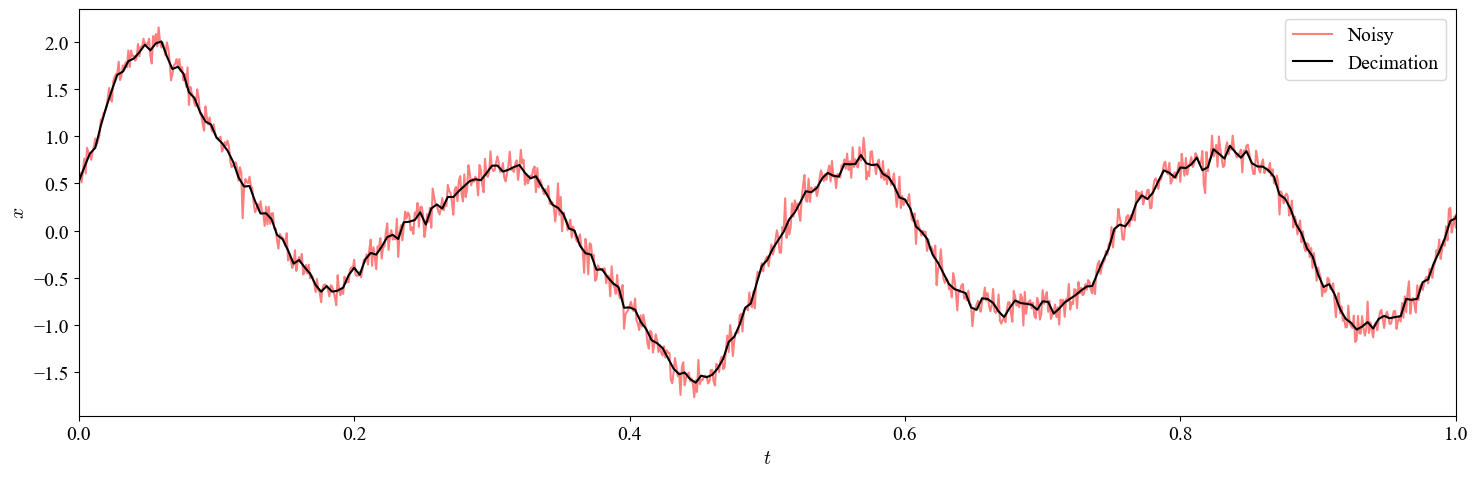

In [19]:
plt.figure(figsize=(15, 5))
plt.plot(t, x_noisy, "r", alpha=0.5, label="Noisy")
plt.plot(t_dec, x_dec, "k", label="Decimation")
plt.xlim(0, 1)
plt.xlabel(r"$t$")
plt.ylabel(r"$x$")
plt.legend()
plt.tight_layout()
plt.show()